# Modules

In [ ]:
import pandas as pd
import re
import string

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Load Data

In [ ]:
non_ai = pd.read_csv("/content/nonai_postings.csv")

In [ ]:
non_ai.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column                              Non-Null Count  Dtype 
---  ------                              --------------  ----- 
 0   Unnamed: 0                          1000 non-null   int64 
 1   ID                                  1000 non-null   object
 2   TITLE_NAME                          1000 non-null   object
 3   LOT_V7_SPECIALIZED_OCCUPATION_NAME  1000 non-null   object
 4   BODY                                1000 non-null   object
dtypes: int64(1), object(4)
memory usage: 39.2+ KB


In [ ]:
non_ai.head()

,Unnamed: 0,ID,TITLE_NAME,LOT_V7_SPECIALIZED_OCCUPATION_NAME,BODY
0,0,376794e602ccc8ed8dd9d48297daf2f33019639a,Public Health Assistants,Unclassified Specialized Occupation,"Public Health Assistant, Bureau of Sexually Tr..."
1,1,cd3fadc8c93b8cfeb893d740b38ed19eca30df66,Early Intervention Occupational Therapists,Physical Therapist,Physical Therapist (PT)- Early Intervention an...
2,2,6a04d9d1e5e3e3f62ee57bd8a41a31de5460f7b7,Footwear Managers,Assistant Sales Manager,Assistant Sales Manager - Famous Footwear3315 ...
3,3,a02da56c9445df6e98eaef37a04a7bdf42c59e42,Life Insurance Agents,Insurance Sales Agent (General),× Close Why Register? \n\t\tCollege Recruiter ...
4,4,35ccab4cbde399945ea6a0c6c1dacdb40aa1a059,Directors of Clinical Informatics,Clinical Director,All jobs \n\n Director of Clinical Informatics...


# Generate AI Postings

In [ ]:
from openai import OpenAI
import time
import asyncio
from openai import AsyncOpenAI
from tenacity import retry, stop_after_attempt, wait_exponential, retry_if_exception_type
import openai
import os


In [ ]:

# Use async client for concurrent requests
client = AsyncOpenAI(api_key="API_KEY")

CONCURRENCY = 10
CHECKPOINT_FILE = "checkpoint.csv"

PROMPT_TEMPLATE = """
You are generating synthetic job postings for data augmentation.

Task:
Given the job posting below, create a new job posting with the same structure, tone, and sections, but change:
- company name
- job title (but keep same type of role)
- location
- responsibilities
- requirements
- benefits

Keep:
- formatting
- section order
- professional tone
- similar length

Do NOT copy unique identifiers or exact phrases.

JOB POSTING:
\"\"\"
{body}
\"\"\"

Return only the new job posting.
"""

@retry(
    retry=retry_if_exception_type((openai.RateLimitError, openai.APIConnectionError)),
    wait=wait_exponential(multiplier=1, min=2, max=60),  # exponential backoff
    stop=stop_after_attempt(5)
)
async def generate_job(semaphore, index, body):
    async with semaphore:  # limits concurrency
        response = await client.responses.create(
            model="gpt-4.1-mini",
            input=PROMPT_TEMPLATE.format(body=body)
        )
        return index, response.output_text

async def process_all(df, start_from=0):
    semaphore = asyncio.Semaphore(CONCURRENCY)

    # Only process rows not already done
    pending = [(i, row["BODY"]) for i, row in df.iterrows() if i >= start_from]

    tasks = [generate_job(semaphore, i, body) for i, body in pending]

    results = {}
    completed = 0

    # Process in chunks and checkpoint periodically
    CHUNK = 50
    for batch_start in range(0, len(tasks), CHUNK):
        batch = tasks[batch_start : batch_start + CHUNK]
        batch_results = await asyncio.gather(*batch, return_exceptions=True)

        for result in batch_results:
            if isinstance(result, Exception):
                print(f"Failed after retries: {result}")
            else:
                idx, text = result
                results[idx] = text

        completed += len(batch)
        print(f"Progress: {completed}/{len(tasks)} ({100*completed//len(tasks)}%)")

        # Save checkpoint after each chunk
        df.loc[list(results.keys()), "AI_BODY"] = pd.Series(results)
        df.to_csv(CHECKPOINT_FILE, index=True)
        print(f"Checkpoint saved ({len(results)} results so far)")

    return results

In [ ]:
def load_checkpoint(df):
    """Resume from checkpoint if it exists."""
    if os.path.exists(CHECKPOINT_FILE):
        print("Found checkpoint, resuming...")
        ckpt = pd.read_csv(CHECKPOINT_FILE, index_col=0)
        done = ckpt["AI_BODY"].notna().sum()
        print(f"  {done} rows already completed")
        return ckpt, done
    return df, 0



df, start_from = load_checkpoint(non_ai.copy())
results = await process_all(df, start_from=start_from)
df.loc[list(results.keys()), "AI_BODY"] = pd.Series(results)
df.to_csv("output_final.csv", index=True)
print("Done!")

Found checkpoint, resuming...
  0 rows already completed
Failed after retries: Error code: 401 - {'error': {'message': 'Incorrect API key provided: API_KEY. You can find your API key at https://platform.openai.com/account/api-keys.', 'type': 'invalid_request_error', 'param': None, 'code': 'invalid_api_key'}}
Failed after retries: Error code: 401 - {'error': {'message': 'Incorrect API key provided: API_KEY. You can find your API key at https://platform.openai.com/account/api-keys.', 'type': 'invalid_request_error', 'param': None, 'code': 'invalid_api_key'}}
Failed after retries: Error code: 401 - {'error': {'message': 'Incorrect API key provided: API_KEY. You can find your API key at https://platform.openai.com/account/api-keys.', 'type': 'invalid_request_error', 'param': None, 'code': 'invalid_api_key'}}
Failed after retries: Error code: 401 - {'error': {'message': 'Incorrect API key provided: API_KEY. You can find your API key at https://platform.openai.com/account/api-keys.', 'type':

In [ ]:
df.head()

,Unnamed: 0,ID,TITLE_NAME,LOT_V7_SPECIALIZED_OCCUPATION_NAME,BODY,AI_BODY
0,0,376794e602ccc8ed8dd9d48297daf2f33019639a,Public Health Assistants,Unclassified Specialized Occupation,"Public Health Assistant, Bureau of Sexually Tr...",NaN
1,1,cd3fadc8c93b8cfeb893d740b38ed19eca30df66,Early Intervention Occupational Therapists,Physical Therapist,Physical Therapist (PT)- Early Intervention an...,NaN
2,2,6a04d9d1e5e3e3f62ee57bd8a41a31de5460f7b7,Footwear Managers,Assistant Sales Manager,Assistant Sales Manager - Famous Footwear3315 ...,NaN
3,3,a02da56c9445df6e98eaef37a04a7bdf42c59e42,Life Insurance Agents,Insurance Sales Agent (General),× Close Why Register? \n\t\tCollege Recruiter ...,NaN
4,4,35ccab4cbde399945ea6a0c6c1dacdb40aa1a059,Directors of Clinical Informatics,Clinical Director,All jobs \n\n Director of Clinical Informatics...,NaN


In [ ]:
ai_data = pd.read_csv("/content/ai_postings.csv")

In [ ]:
ai_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column                              Non-Null Count  Dtype 
---  ------                              --------------  ----- 
 0   Unnamed: 0                          1000 non-null   int64 
 1   ID                                  1000 non-null   object
 2   TITLE_NAME                          1000 non-null   object
 3   LOT_V7_SPECIALIZED_OCCUPATION_NAME  1000 non-null   object
 4   BODY                                1000 non-null   object
 5   AI_BODY                             1000 non-null   object
dtypes: int64(1), object(5)
memory usage: 47.0+ KB


# Cleaning and Pre-processing

In [ ]:
# standardize column names

ai_data = ai_data.rename(columns={
    "AI_BODY": "text"
})


non_ai = non_ai.rename(columns={
    "BODY": "text"
})


In [ ]:
ai_data= ai_data[["text"]].copy()
non_ai = non_ai[["text"]].copy()

In [ ]:
ai_data["label"] = 1
non_ai["label"] = 0

In [ ]:
df = pd.concat([ai_data, non_ai], ignore_index=True)

In [ ]:
def clean_text(text):
    if pd.isna(text):
        return ""

    # Lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r"http\S+|www\S+", "", text)

    # Remove emails
    text = re.sub(r"\S+@\S+", "", text)

    # Remove numbers
    text = re.sub(r"\d+", "", text)

    # Remove punctuation
    text = text.translate(str.maketrans("", "", string.punctuation))

    # Remove extra whitespace
    text = re.sub(r"\s+", " ", text).strip()

    return text


In [ ]:
# Apply cleaning
df["clean_text"] = df["text"].apply(clean_text)


In [ ]:
df = df[df["clean_text"].str.len() > 30]

In [ ]:
print(df.head())
print(df["label"].value_counts())

                                                text  label  \
0  """\nCommunity Health Coordinator, Department ...      1   
1  """\nOccupational Therapist (OT) - Pediatric O...      1   
2  """\nRetail Sales Supervisor - Urban Sole Co.4...      1   
3  """\n× Close Why Register? \n\t\tCollege Recru...      1   
4  All jobs \n\n Head of Healthcare Data Integrat...      1   

                                          clean_text  
0  community health coordinator department of wel...  
1  occupational therapist ot pediatric outpatient...  
2  retail sales supervisor urban sole co maple st...  
3  × close why register college recruiter is the ...  
4  all jobs head of healthcare data integration h...  
label
1    1000
0    1000
Name: count, dtype: int64


## How Cleaning and processing changes the data

In [ ]:
print("ORIGINAL:\n", df["text"].iloc[0])
print("\nCLEANED:\n", df["clean_text"].iloc[0])

ORIGINAL:
 """
Community Health Coordinator, Department of Wellness and Preventive Care

Chicago CITY HEALTH DEPARTMENT

150 reviews

-

Chicago, IL

Chicago CITY HEALTH DEPARTMENT

150 reviews

Read what people are saying about working here.

$18.50 - $22.75 an hour

The Department of Wellness and Preventive Care (DWPC) is dedicated to enhancing the overall health and well-being of Chicago residents through outreach, education, and support services. The department offers community-based programs focusing on chronic disease prevention, health screenings, and wellness promotion. DWPC operates multiple community health centers across Chicago neighborhoods and is seeking a Community Health Coordinator to join our team and support these initiatives.

DUTIES WILL INCLUDE BUT NOT BE LIMITED TO:

* -Support healthcare providers by preparing community outreach materials, assisting in group education sessions, and facilitating communication with clients.

* -Manage scheduling and setup for comm

In [ ]:
df.head()

,text,label,clean_text
0,"""""""\nCommunity Health Coordinator, Department ...",1,community health coordinator department of wel...
1,"""""""\nOccupational Therapist (OT) - Pediatric O...",1,occupational therapist ot pediatric outpatient...
2,"""""""\nRetail Sales Supervisor - Urban Sole Co.4...",1,retail sales supervisor urban sole co maple st...
3,"""""""\n× Close Why Register? \n\t\tCollege Recru...",1,× close why register college recruiter is the ...
4,All jobs \n\n Head of Healthcare Data Integrat...,1,all jobs head of healthcare data integration h...


# Baseline Model

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    RocCurveDisplay
)

import matplotlib.pyplot as plt

## Bag of Words

## TF-IDF

# Transformer Model

## BERT

In [ ]:
## load data, we can use non-preprocessed data here
X = df["text"]
y = df["label"]

In [ ]:
from sklearn.model_selection import train_test_split


train_texts, test_texts, train_labels, test_labels = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
from transformers import AutoTokenizer


tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

train_encodings = tokenizer(
    train_texts.tolist(),
    truncation=True,
    padding=True,
    max_length=512
)

test_encodings = tokenizer(
    test_texts.tolist(),
    truncation=True,
    padding=True,
    max_length=512
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [ ]:
import torch

class JobDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels.tolist()

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = JobDataset(train_encodings, train_labels)
test_dataset = JobDataset(test_encodings, test_labels)

In [ ]:
from transformers import AutoModelForSequenceClassification

bert_model = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=2
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./results",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=4,
    weight_decay=0.01,
    logging_dir="./logs",
    save_strategy="no"
)

[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, roc_auc_score

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    probs = torch.nn.functional.softmax(torch.tensor(logits), dim=1)[:, 1].numpy()
    preds = np.argmax(logits, axis=1)

    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average="binary")
    acc = accuracy_score(labels, preds)
    roc = roc_auc_score(labels, probs)

    return {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "roc_auc": roc
    }

In [ ]:
from transformers import Trainer

trainer = Trainer(
    model=bert_model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics
)

trainer.train()

Step,Training Loss


Step,Training Loss
500,0.114399


TrainOutput(global_step=800, training_loss=0.07607706040143966, metrics={'train_runtime': 604.4303, 'train_samples_per_second': 10.588, 'train_steps_per_second': 1.324, 'total_flos': 1683910754304000.0, 'train_loss': 0.07607706040143966, 'epoch': 4.0})

In [ ]:
trainer.evaluate()

Training Loss,Validation Loss,Step,Accuracy,Precision,Recall,F1,Roc Auc
0.114399,0.087014,800,0.985000,1.000000,0.970000,0.984772,0.996875


{'eval_loss': 0.08701444417238235,
 'eval_accuracy': 0.985,
 'eval_precision': 1.0,
 'eval_recall': 0.97,
 'eval_f1': 0.9847715736040609,
 'eval_roc_auc': 0.9968750000000001}

In [ ]:
"""## LOAD JOB_POSTINGS CSV AND APPLY TRAINED BERT"""

new_df = pd.read_csv("/content/job_postings.csv")

# ── Adjust this to your actual text column name ──
new_df = new_df.rename(columns={"BODY": "text"})
new_df["text"] = new_df["text"].fillna("").astype(str)

new_df.head()

# ── Device + move model BEFORE inference ──
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
bert_model = bert_model.to(device)
bert_model.eval()

import torch
import numpy as np
import os

BATCH_SIZE = 8                          # small batches = no OOM
CHECKPOINT_PATH = "/content/bert_preds_checkpoint.csv"

In [ ]:
# Resume from checkpoint if it exists
if os.path.exists(CHECKPOINT_PATH):
    print("Checkpoint found, resuming...")
    checkpoint_df = pd.read_csv(CHECKPOINT_PATH)
    done_indices = set(checkpoint_df["original_index"].tolist())
    print(f"  {len(done_indices)} rows already done")
else:
    checkpoint_df = pd.DataFrame(columns=["original_index", "bert_pred", "bert_prob"])
    done_indices = set()

texts = new_df["text"].tolist()
indices = list(new_df.index)

all_rows = []



Checkpoint found, resuming...
  10808 rows already done


In [ ]:
for batch_start in range(0, len(texts), BATCH_SIZE):
    batch_indices = indices[batch_start : batch_start + BATCH_SIZE]

    # Skip already-processed rows
    if all(i in done_indices for i in batch_indices):
        continue

    batch_texts = texts[batch_start : batch_start + BATCH_SIZE]

    encodings = tokenizer(
        batch_texts,
        truncation=True,
        padding=True,
        max_length=512,
        return_tensors="pt"
    )
    encodings = {k: v.to(device) for k, v in encodings.items()}

    with torch.no_grad():
        outputs = bert_model(**encodings)
        logits = outputs.logits
        probs = torch.nn.functional.softmax(logits, dim=1)[:, 1].cpu().numpy()
        preds = torch.argmax(logits, dim=1).cpu().numpy()

    # Free GPU memory after each batch
    del encodings, outputs, logits
    torch.cuda.empty_cache()

    for i, idx in enumerate(batch_indices):
        all_rows.append({
            "original_index": idx,
            "bert_pred": preds[i],
            "bert_prob": probs[i]
        })

    # Save checkpoint every 50 batches
    if (batch_start // BATCH_SIZE) % 50 == 0:
        batch_df = pd.DataFrame(all_rows)
        checkpoint_df = pd.concat([checkpoint_df, batch_df], ignore_index=True)
        checkpoint_df.to_csv(CHECKPOINT_PATH, index=False)
        all_rows = []
        print(f"Checkpoint saved at index {batch_start}/{len(texts)}")


Checkpoint saved at index 11200/100000
Checkpoint saved at index 11600/100000
Checkpoint saved at index 12000/100000
Checkpoint saved at index 12400/100000
Checkpoint saved at index 12800/100000
Checkpoint saved at index 13200/100000
Checkpoint saved at index 13600/100000
Checkpoint saved at index 14000/100000
Checkpoint saved at index 14400/100000
Checkpoint saved at index 14800/100000
Checkpoint saved at index 15200/100000
Checkpoint saved at index 15600/100000
Checkpoint saved at index 16000/100000
Checkpoint saved at index 16400/100000
Checkpoint saved at index 16800/100000
Checkpoint saved at index 17200/100000
Checkpoint saved at index 17600/100000
Checkpoint saved at index 18000/100000
Checkpoint saved at index 18400/100000
Checkpoint saved at index 18800/100000
Checkpoint saved at index 19200/100000
Checkpoint saved at index 19600/100000
Checkpoint saved at index 20000/100000
Checkpoint saved at index 20400/100000
Checkpoint saved at index 20800/100000
Checkpoint saved at index

In [ ]:
# Save any remaining rows
if all_rows:
    batch_df = pd.DataFrame(all_rows)
    checkpoint_df = pd.concat([checkpoint_df, batch_df], ignore_index=True)
    checkpoint_df.to_csv(CHECKPOINT_PATH, index=False)

# Merge predictions back into new_df
checkpoint_df = checkpoint_df.set_index("original_index")
new_df["bert_pred"] = checkpoint_df["bert_pred"]
new_df["bert_prob"] = checkpoint_df["bert_prob"]

print(new_df[["text", "bert_pred", "bert_prob"]].head())


                                                text  bert_pred  bert_prob
0  QR Code Link to This Post Pool cleaning techni...          0   0.001376
1  Warehouse Frontier - 3.6 Racine, WI Quick Appl...          0   0.016721
2  HOSPITALITY BUSSER - UP TO $19 PER HOUR Mendoc...          0   0.000294
3  Payroll Director (Cannabis Industry) Cannabis ...          0   0.000780
4  Learning Technology Specialist Ohio University...          1   0.999407


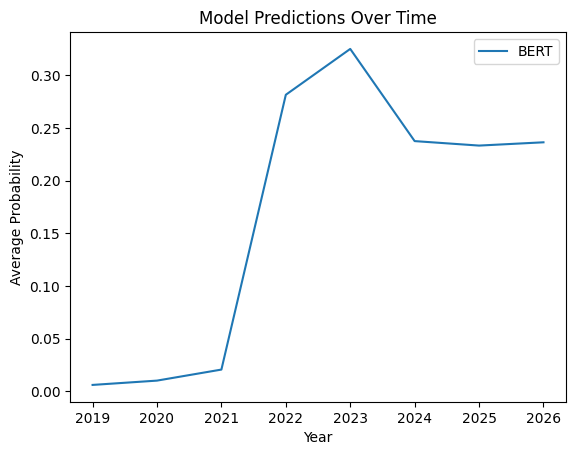

In [ ]:
# ── Visualization ──
import matplotlib.pyplot as plt

yearly = new_df.groupby("YEAR(POSTED)")["bert_prob"].mean().reset_index()

plt.figure()
plt.plot(yearly["YEAR(POSTED)"], yearly["bert_prob"], label="BERT")
plt.xlabel("Year")
plt.ylabel("Average Probability")
plt.title("Model Predictions Over Time")
plt.legend()
plt.show()

In [ ]:
new_df.to_csv("/content/job_postings_with_predictions.csv", index=False)
print("job_postings_with_predictions.csv saved successfully to /content/")

job_postings_with_predictions.csv saved successfully to /content/


/tmp/ipykernel_26851/2153138686.py:16: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout() # Adjust layout to prevent labels from being cut off


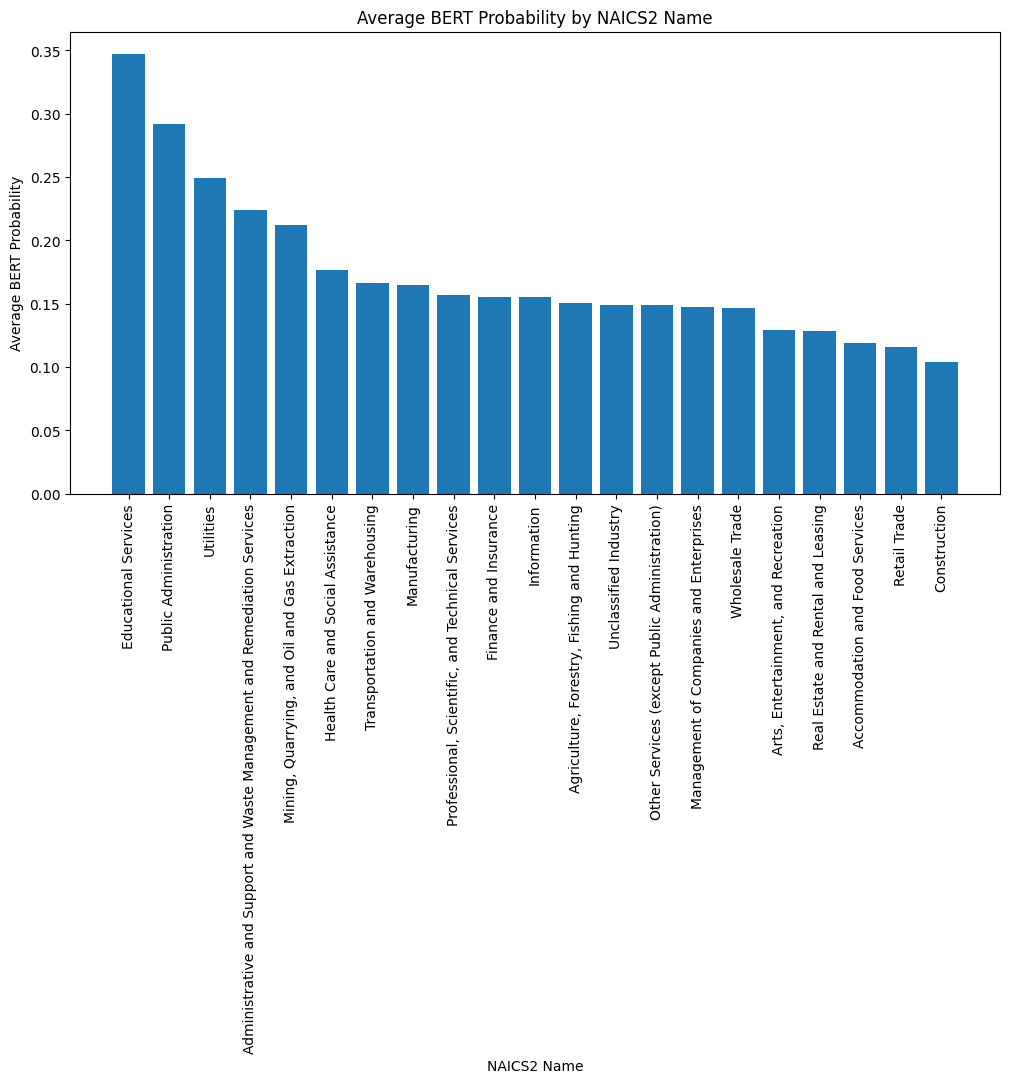

In [ ]:
import matplotlib.pyplot as plt

# Group by NAICS2_NAME and calculate the average bert_prob
naics_yearly = new_df.groupby("NAICS2_NAME")["bert_prob"].mean().reset_index()

# Sort by bert_prob for better visualization (optional)
naics_yearly = naics_yearly.sort_values(by="bert_prob", ascending=False)

# Create the bar plot
plt.figure(figsize=(12, 6))
plt.bar(naics_yearly["NAICS2_NAME"], naics_yearly["bert_prob"])
plt.xlabel("NAICS2 Name")
plt.ylabel("Average BERT Probability")
plt.title("Average BERT Probability by NAICS2 Name")
plt.xticks(rotation=90) # Rotate labels to prevent overlap
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

       STATE_NAME  AI_Generated_Postings_Count
0      California                         1992
1           Texas                         1218
2         Florida                         1065
3        New York                          721
4        Illinois                          719
5    Pennsylvania                          605
6            Ohio                          537
7   Massachusetts                          510
8        Virginia                          509
9  North Carolina                          477


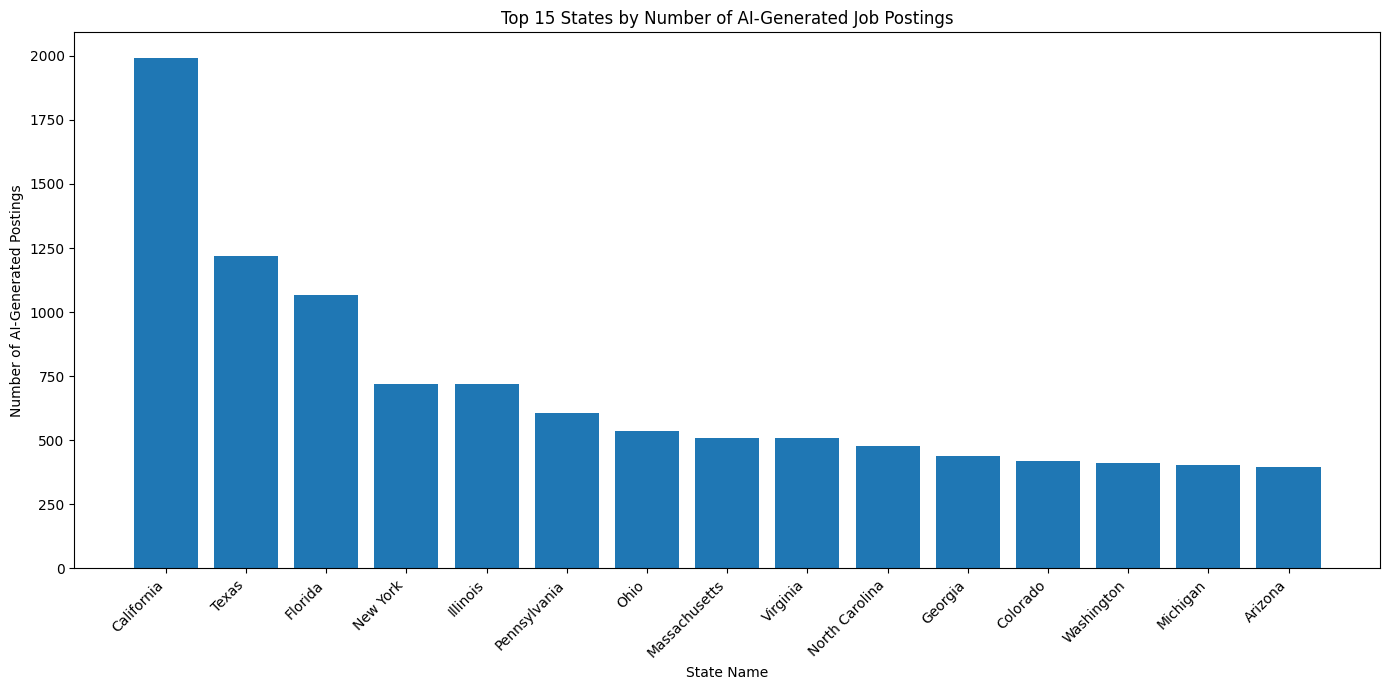

In [ ]:
# Filter for AI-generated postings (where bert_pred is 1)
ai_generated_postings = new_df[new_df['bert_pred'] == 1]

# Group by STATE_NAME and count the number of AI-generated postings
ai_postings_by_state = ai_generated_postings['STATE_NAME'].value_counts().reset_index()
ai_postings_by_state.columns = ['STATE_NAME', 'AI_Generated_Postings_Count']

print(ai_postings_by_state.head(10))

import matplotlib.pyplot as plt

# Create a bar plot for the top N states (e.g., top 15)
plt.figure(figsize=(14, 7))
plt.bar(ai_postings_by_state['STATE_NAME'].head(15), ai_postings_by_state['AI_Generated_Postings_Count'].head(15))
plt.xlabel('State Name')
plt.ylabel('Number of AI-Generated Postings')
plt.title('Top 15 States by Number of AI-Generated Job Postings')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
# Filter for AI-generated postings
ai_generated_postings_multi = new_df[new_df['bert_pred'] == 1]

# Group by STATE_NAME, NAICS2_NAME, and YEAR(POSTED) and count the number of AI-generated postings
ai_postings_multi_dim = ai_generated_postings_multi.groupby(['STATE_NAME', 'NAICS2_NAME', 'YEAR(POSTED)']).size().reset_index(name='AI_Generated_Postings_Count')

# Sort by count in descending order
ai_postings_multi_dim = ai_postings_multi_dim.sort_values(by='AI_Generated_Postings_Count', ascending=False)

print("Top AI-Generated Postings by State, NAICS2_NAME, and Year:")
display(ai_postings_multi_dim.head(10))

Top AI-Generated Postings by State, NAICS2_NAME, and Year:


,STATE_NAME,NAICS2_NAME,YEAR(POSTED),AI_Generated_Postings_Count
256,California,Administrative and Support and Waste Managemen...,2022,158
356,California,Unclassified Industry,2022,113
290,California,Health Care and Social Assistance,2022,92
257,California,Administrative and Support and Waste Managemen...,2023,82
259,California,Administrative and Support and Waste Managemen...,2025,82
323,California,"Professional, Scientific, and Technical Services",2022,74
598,Florida,Health Care and Social Assistance,2022,68
2843,Texas,Administrative and Support and Waste Managemen...,2022,64
306,California,Manufacturing,2022,64
276,California,Educational Services,2023,61


/tmp/ipykernel_26851/4104977105.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top_10_combinations['Combined_Label'] = top_10_combinations['STATE_NAME'] + ' - ' + top_10_combinations['NAICS2_NAME'] + ' (' + top_10_combinations['YEAR(POSTED)'].astype(str) + ')'
/tmp/ipykernel_26851/4104977105.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Combined_Label', y='AI_Generated_Postings_Count', data=top_10_combinations, palette='viridis')


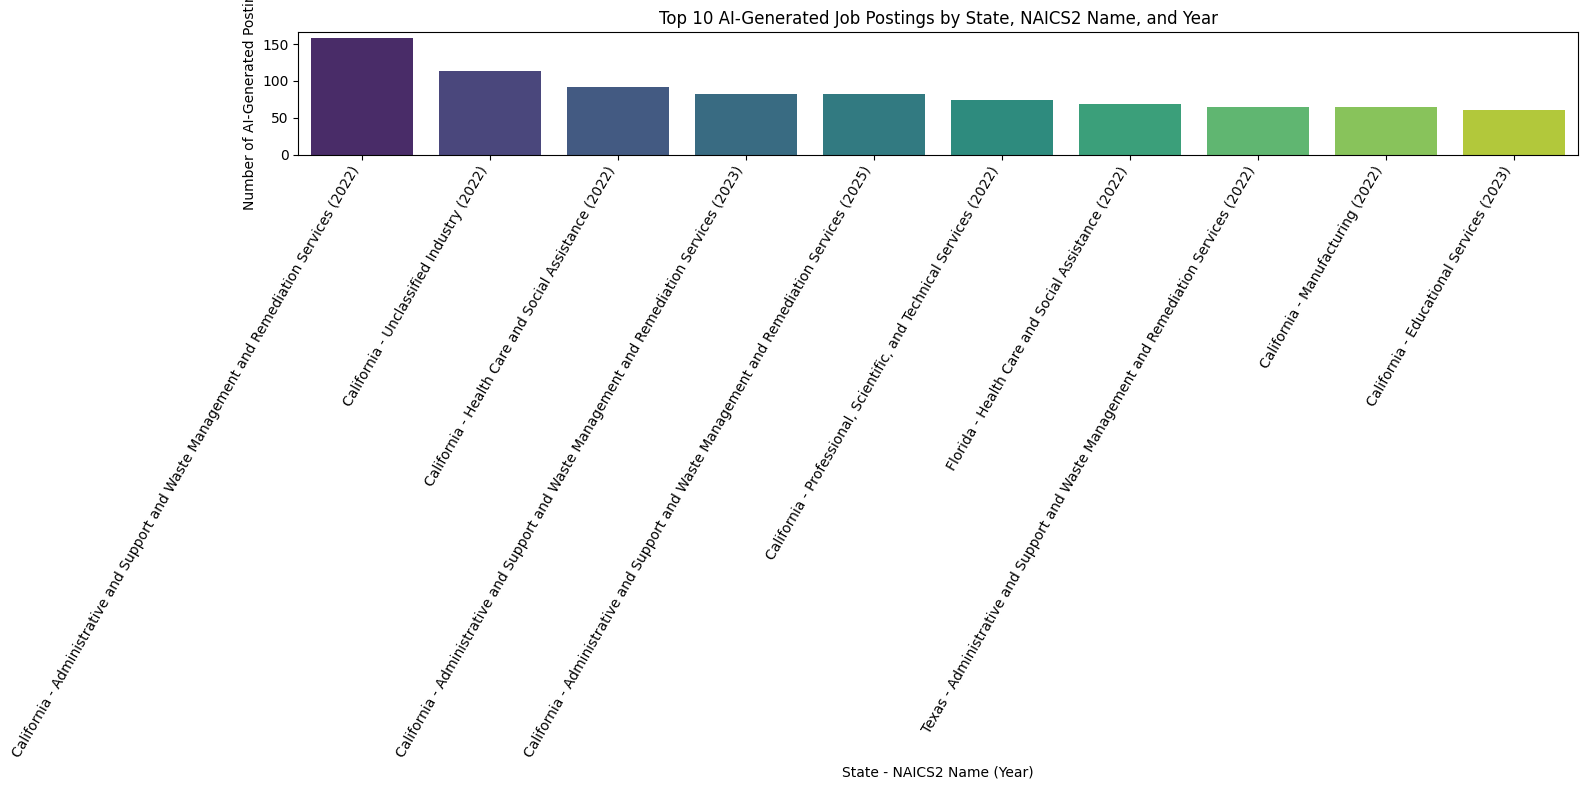

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# For visualization, let's take the top 10 combinations
top_10_combinations = ai_postings_multi_dim.head(10)

# Create a combined label for the x-axis for better readability
top_10_combinations['Combined_Label'] = top_10_combinations['STATE_NAME'] + ' - ' + top_10_combinations['NAICS2_NAME'] + ' (' + top_10_combinations['YEAR(POSTED)'].astype(str) + ')'

plt.figure(figsize=(16, 8))
sns.barplot(x='Combined_Label', y='AI_Generated_Postings_Count', data=top_10_combinations, palette='viridis')
plt.xlabel('State - NAICS2 Name (Year)')
plt.ylabel('Number of AI-Generated Postings')
plt.title('Top 10 AI-Generated Job Postings by State, NAICS2 Name, and Year')
plt.xticks(rotation=60, ha='right') # Rotate labels for better readability
plt.tight_layout()
plt.show()

In [ ]:
# Group by STATE_NAME and NAICS2_NAME, then calculate average bert_prob and count of postings
insights_by_state_naics = new_df.groupby(['STATE_NAME', 'NAICS2_NAME']).agg(
    Average_BERT_Probability=('bert_prob', 'mean'),
    Postings_Count=('bert_pred', 'size') # Using bert_pred column to count rows
).reset_index()

# Sort for better readability (e.g., by state, then by average probability)
insights_by_state_naics = insights_by_state_naics.sort_values(
    by=['STATE_NAME', 'Average_BERT_Probability'],
    ascending=[True, False]
)

print("Average BERT Probability and Postings Count by State and NAICS2 Category:")
display(insights_by_state_naics.head(20)) # Display the first 20 rows

Average BERT Probability and Postings Count by State and NAICS2 Category:


,STATE_NAME,NAICS2_NAME,Average_BERT_Probability,Postings_Count
19,Alabama,Utilities,0.500280,6
11,Alabama,"Mining, Quarrying, and Oil and Gas Extraction",0.499495,2
5,Alabama,Educational Services,0.352285,54
1,Alabama,Administrative and Support and Waste Managemen...,0.288599,177
17,Alabama,Transportation and Warehousing,0.250072,28
12,Alabama,Other Services (except Public Administration),0.230499,26
3,Alabama,"Arts, Entertainment, and Recreation",0.222369,9
10,Alabama,Manufacturing,0.220095,104
13,Alabama,"Professional, Scientific, and Technical Services",0.216559,124
15,Alabama,Real Estate and Rental and Leasing,0.190659,21


## LOAD JOB_POSTINGS CSV AND APPLY TRAINED BERT¶